In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter     # Counter helps count word frequency
from wordcloud import WordCloud     # wordcloud generates word frequency visualization
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
# Load FR/NFR dataset
fr_nfr_df = pd.read_csv("../dataset/PROMISE.csv")

# Load NFR categories dataset
nfr_df = pd.read_excel("../dataset/NFR_categories_dataset_balanced.xlsx")

In [3]:
fr_nfr_df.head()

,Requirement,_class_,Type
0,The system shall refresh the display every 60 ...,PE,NFR
1,The application shall match the color of the s...,LF,NFR
2,If projected the data must be readable. On a...,US,NFR
3,The product shall be available during normal b...,A,NFR
4,If projected the data must be understandable....,US,NFR


In [4]:
fr_nfr_df.drop('_class_', axis=1, inplace=True)
fr_nfr_df.head()

,Requirement,Type
0,The system shall refresh the display every 60 ...,NFR
1,The application shall match the color of the s...,NFR
2,If projected the data must be readable. On a...,NFR
3,The product shall be available during normal b...,NFR
4,If projected the data must be understandable....,NFR


In [5]:
nfr_df.head()

,RequirementText,label
0,The system shall refresh the display every 60 ...,PE
1,If projected the data must be readable. On a...,US
2,The product shall be available during normal b...,A
3,If projected the data must be understandable....,US
4,The product shall ensure that it can only be a...,SE


In [6]:
print("FR/NFR dataset shape:", fr_nfr_df.shape)
print("NFR dataset shape:", nfr_df.shape)

FR/NFR dataset shape: (969, 2)
NFR dataset shape: (744, 2)


In [7]:
print("Missing values FR/NFR")
print(fr_nfr_df.isnull().sum())

print("Missing values NFR")
print(nfr_df.isnull().sum())

Missing values FR/NFR
Requirement    0
Type           0
dtype: int64
Missing values NFR
RequirementText    0
label              0
dtype: int64


In [8]:
fr_nfr_df.dropna(subset=['Type'], inplace=True)
print(fr_nfr_df.isnull().sum())
print(fr_nfr_df.shape)

Requirement    0
Type           0
dtype: int64
(969, 2)


## Class Distribution

In [9]:
print("FR/NFR class distribution")
print(fr_nfr_df['Type'].value_counts())

FR/NFR class distribution
Type
NFR    525
FR     444
Name: count, dtype: int64


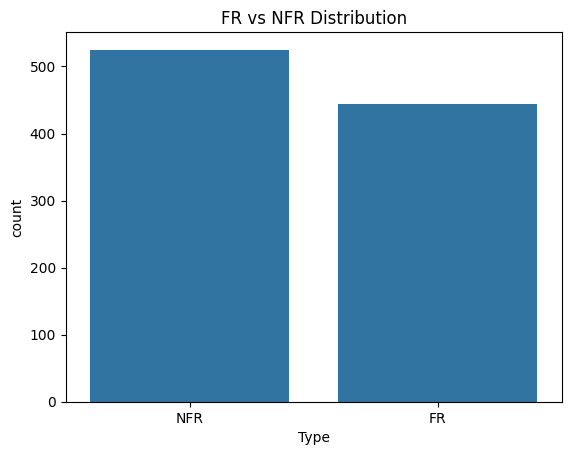

In [10]:
sns.countplot(x="Type", data=fr_nfr_df)
plt.title("FR vs NFR Distribution")
plt.show()

## NFR Category Distribution

In [11]:
print("NFR class distribution")
print(nfr_df['label'].value_counts())

NFR class distribution
label
PE    125
US    125
SE    125
SC    124
MN    123
A     122
Name: count, dtype: int64


## Sentence Length Analysis
This helps detect:
- overly short sentences
- noisy sentences

In [12]:
fr_nfr_df["sentence_length"] = fr_nfr_df["Requirement"].apply(lambda x: len(x.split()))

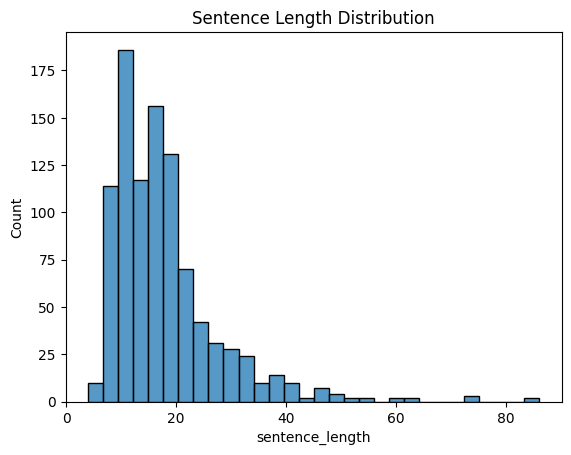

In [13]:
sns.histplot(fr_nfr_df["sentence_length"], bins=30)
plt.title("Sentence Length Distribution")
plt.show()

In [14]:
print(fr_nfr_df['sentence_length'].mean())

17.91434468524252


## Detect Duplicate Sentences

In [15]:
duplicates = fr_nfr_df.duplicated(subset=["Requirement"]).sum()
print("Duplicate sentences:", duplicates)

Duplicate sentences: 0


In [16]:
fr_nfr_df.drop_duplicates(subset=["Requirement"], inplace=True)
duplicates = fr_nfr_df.duplicated(subset=["Requirement"]).sum()
print("Duplicate sentences:", duplicates)

Duplicate sentences: 0


In [17]:
fr_nfr_df.shape

(969, 3)

In [18]:
duplicates = nfr_df.duplicated(subset=["RequirementText"]).sum()
print("Duplicate sentences:", duplicates)

Duplicate sentences: 0


## Vocab analysis

In [19]:
all_words = " ".join(fr_nfr_df["Requirement"])
words = all_words.split()
word_counts = Counter(words)
print(word_counts.most_common(20))

[('the', 1138), ('The', 707), ('shall', 703), ('to', 660), ('of', 456), ('be', 424), ('a', 373), ('system', 365), ('and', 339), ('product', 279), ('for', 189), ('user', 172), ('in', 154), ('will', 153), ('must', 146), ('able', 120), ('on', 114), ('with', 111), ('allow', 108), ('by', 105)]


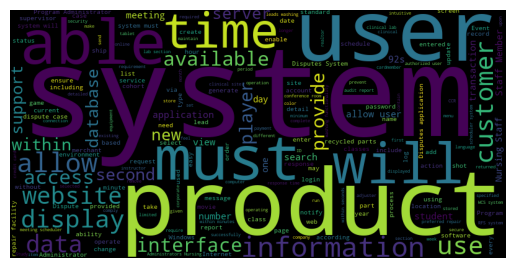

In [20]:
wordcloud = WordCloud(width=800, height=400).generate(all_words)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

## Detect Labeleing problem
Check if same sentence has different labels.

In [21]:
conflicts = fr_nfr_df.groupby("Requirement")["Type"].nunique()
conflicts = conflicts[conflicts > 1]

print("Conflicting labels:")
print(conflicts)

Conflicting labels:
Series([], Name: Type, dtype: int64)


## Compare FR vs NFR vocab

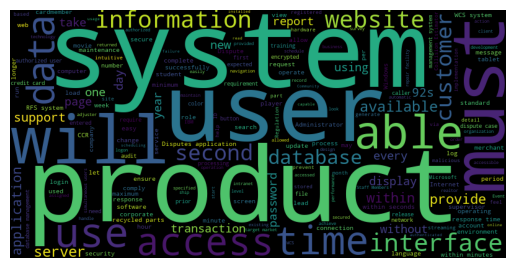

In [22]:
fr_words = " ".join(fr_nfr_df[fr_nfr_df["Type"]=="FR"]["Requirement"])
nfr_words = " ".join(fr_nfr_df[fr_nfr_df["Type"]=="NFR"]["Requirement"])

fr_words_count = Counter(fr_words)
nfr_words_count = Counter(nfr_words)

wordcloud = WordCloud(width=800, height=400).generate(nfr_words)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()



## TF-IDF Keyword Discovery

This shows important words for classification.

In [23]:
vectorizer = TfidfVectorizer(max_features=50)
X = vectorizer.fit_transform(fr_nfr_df["Requirement"])
print(vectorizer.get_feature_names_out())

['able' 'access' 'all' 'allow' 'an' 'and' 'any' 'application' 'are' 'as'
 'available' 'be' 'by' 'data' 'database' 'display' 'disputes' 'each' 'for'
 'from' 'have' 'in' 'information' 'interface' 'is' 'must' 'not' 'of' 'on'
 'only' 'or' 'product' 'program' 'provide' 'seconds' 'shall' 'should'
 'system' 'that' 'the' 'their' 'time' 'to' 'use' 'user' 'users' 'website'
 'will' 'with' 'within']


In [ ]:
# fr_nfr_df.to_csv("../dataset/binary_classifier_dataset.csv")
# nfr_df.to_csv("../dataset/NFR_categories_dataset.csv")